<a href="https://colab.research.google.com/github/hridibazaman03/220142_KNN/blob/main/220142_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
    confusion_matrix, roc_curve
)

from sklearn.decomposition import PCA

In [ ]:
url = "https://raw.githubusercontent.com/hridibazaman03/220142_KNN/main/test.csv"

df = pd.read_csv(url)

print(df.shape)
df.head()

In [ ]:
df.columns = df.columns.str.strip()

In [49]:
df = df.dropna(subset=["satisfaction"])

df["satisfaction"] = df["satisfaction"].map({
    "satisfied": 1,
    "neutral or dissatisfied": 0
})

df = df.dropna(subset=["satisfaction"])

df["satisfaction"] = df["satisfaction"].astype(int)

In [ ]:
X = df.drop("satisfaction", axis=1)
y = df["satisfaction"]

print(X.shape, y.shape)

In [ ]:
imputer = SimpleImputer(strategy="most_frequent")
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

In [ ]:
label_encoders = {}

for col in X.select_dtypes(include="object").columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

In [ ]:
error_rate = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    error_rate.append(np.mean(pred != y_val))

plt.plot(range(1, 21), error_rate, marker="o")
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.show()

In [40]:
param_grid = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'metric': 'manhattan', 'n_neighbors': 8, 'weights': 'distance'}


In [41]:
best_knn = grid.best_estimator_
best_knn.fit(X_train, y_train)

KNeighborsClassifier(metric='manhattan', n_neighbors=8, weights='distance')

In [42]:
y_pred = best_knn.predict(X_test)
y_prob = best_knn.predict_proba(X_test)[:, 1]

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.9235309212214524
Precision: 0.9268882175226586
Recall: 0.896551724137931
F1 Score: 0.9114676173499703
AUC: 0.9751071186226787


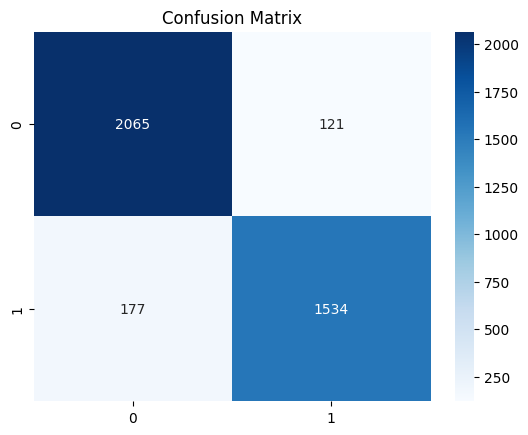

In [44]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

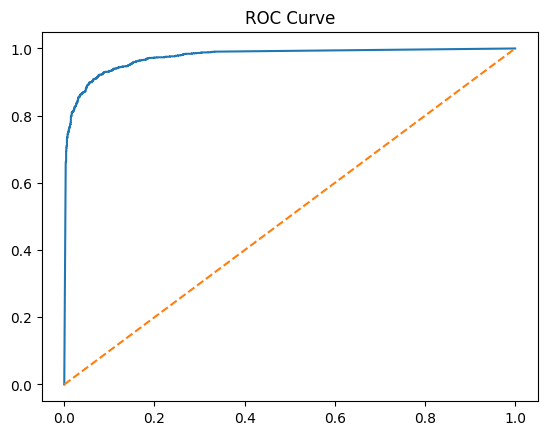

In [45]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],"--")
plt.title("ROC Curve")
plt.show()

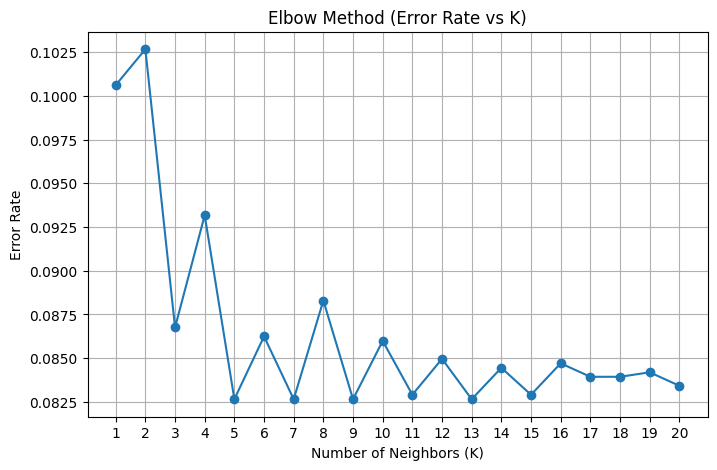

Best K (lowest error): 5


In [50]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

error_rate = []

k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_val)
    error = np.mean(y_pred != y_val)
    error_rate.append(error)

plt.figure(figsize=(8,5))
plt.plot(k_range, error_rate, marker='o')
plt.title("Elbow Method (Error Rate vs K)")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Error Rate")
plt.xticks(k_range)
plt.grid(True)
plt.show()

best_k = k_range[np.argmin(error_rate)]
print("Best K (lowest error):", best_k)

In [46]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

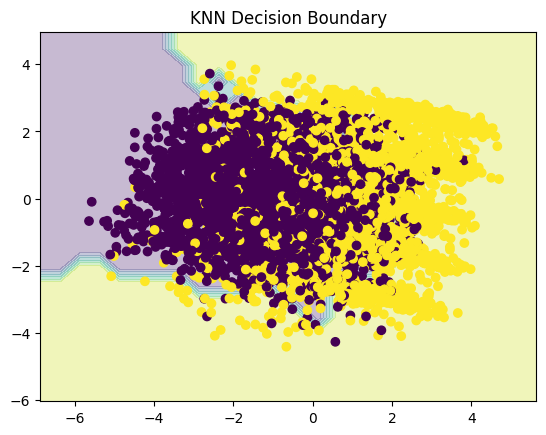

In [47]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pca, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_2d = KNeighborsClassifier(n_neighbors=best_knn.n_neighbors)
model_2d.fit(X_train_p, y_train_p)

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.5),
    np.arange(y_min, y_max, 0.5)
)

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_test_p[:,0], X_test_p[:,1], c=y_test_p)
plt.title("KNN Decision Boundary")
plt.show()